# Questao 4 - Dados 
Problemática: alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.
Causa:

    O sistema de vendas (vendas_2023_2024.csv) registra valores em real BRL
    O catálogo de fornecedores (custos_importacao.json) registra custos unitários em dollar USD
    O câmbio varia diariamente 

Objetivo:Cruzar o custo em dólar do dia da venda com o valor de venda em reais
para identificar onde houve prejuízo real.



### 1. Importação de Bibliotecas e Requisição

In [17]:
# importação de bibliotecas
import requests
import pandas as pd
import sqlite3

In [18]:
# URL da API do Banco Central com dados de 20 até 2025.
url_bcb = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-04-2016'&@dataFinalCotacao='12-31-2025'&$top=10000&$format=json&$select=cotacaoCompra,cotacaoVenda,dataHoraCotacao"

In [19]:
# Fazendo a requisição
response = requests.get(url_bcb)
dados_json = response.json()

### 2. Extração dos valores

In [21]:
# Extraindo os dados a partir da chave 'value'
df_cambio = pd.DataFrame(dados_json['value'])


In [22]:
# Visualizando as primeiras linhas para conferência
print("Cotações carregadas com sucesso:")
df_cambio.head()

Cotações carregadas com sucesso:


,cotacaoCompra,cotacaoVenda,dataHoraCotacao
0,4.0380,4.0387,2016-01-04 13:12:41.021
1,4.0108,4.0114,2016-01-05 13:12:41.306
2,4.0297,4.0303,2016-01-06 13:08:04.506
3,4.0469,4.0475,2016-01-07 13:07:20.817
4,4.0244,4.0250,2016-01-08 13:11:21.614


### 3. Padronização da data para cruzamento de dados

In [23]:
# Convertendo para formato de data e extraindo apenas o dia
df_cambio['data_ajustada'] = pd.to_datetime(df_cambio['dataHoraCotacao']).dt.date

df_cambio['data_ajustada'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2511 entries, 0 to 2510
Series name: data_ajustada
Non-Null Count  Dtype 
--------------  ----- 
2511 non-null   object
dtypes: object(1)
memory usage: 19.7+ KB


In [24]:
# Renomeando a coluna cotacaoVenda para facilitar o cálculo do prejuízo
df_cambio = df_cambio.rename(columns={'cotacaoVenda': 'taxa_venda_bcb'})

# Mantendo apenas as colunas necessárias para a LH Nautical
df_cambio = df_cambio[['data_ajustada', 'taxa_venda_bcb']]


In [25]:
df_cambio.sample(5)

,data_ajustada,taxa_venda_bcb
506,2018-01-10,3.2467
1195,2020-10-07,5.6018
1135,2020-07-14,5.4288
2105,2024-05-27,5.1704
1217,2020-11-10,5.3696


### 4. Codigo de Integração das APIs e Cálculo de prejuízo

In [26]:
# Carregar e padronizar as datas de vendas (Resolvendo a inconsistência crítica)
df_vendas = pd.read_csv('datasets/vendas_2023_2024.csv')

# Tentamos converter as datas; onde falhar (por formatos mistos), usamos dayfirst=True
df_vendas['sale_date_dt'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=False)
df_vendas['sale_date_dt'] = df_vendas['sale_date_dt'].dt.date
df_vendas.to_csv("datasets/vendas_2023_2024.csv")

df_vendas

In [27]:
# 2. Carregar o arquivo de custos normalizado (da Questão 3)
df_custos = pd.read_csv('datasets/custos_importacao_normalizado.csv')
df_custos['start_date'] = pd.to_datetime(df_custos['start_date']).dt.date
df_custos

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18
...,...,...,...,...,...
1255,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2023-06-01,326.88
1256,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-01-31,332.26
1257,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-08-29,292.03
1258,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,2024-10-04,300.96


###  Questões 4.1, 4.2 & 4.3


In [28]:
# Criar conexão SQL em memória
conn = sqlite3.connect(':memory:')

# Salvar tudo como tabelas SQL
df_vendas.to_sql('vendas', conn, index=False, if_exists='replace')
df_custos.to_sql('custos', conn, index=False, if_exists='replace')
df_cambio.to_sql('cambio', conn, index=False, if_exists='replace')

print("Tabelas SQL (vendas, custos e cambio) prontas para consulta.")

Tabelas SQL (vendas, custos e cambio) prontas para consulta.


In [29]:
query_financeiro = """
WITH Vendas_Com_Cambio AS (
    -- Une vendas com a cotação do BCB do dia exato
    SELECT 
        v.id_product,
        v.qtd,
        v.total AS receita_brl,
        v.sale_date,
        c.taxa_venda_bcb
    FROM vendas v
    JOIN cambio c ON v.sale_date = c.data_ajustada
),
Custo_Vigente AS (
    -- Calcula o custo BRL usando o custo USD unitário vigente na data
    SELECT 
        vcc.*,
        (SELECT usd_price 
         FROM custos 
         WHERE product_id = vcc.id_product 
           AND start_date <= vcc.sale_date
         ORDER BY start_date DESC LIMIT 1) AS usd_price_unitario
    FROM Vendas_Com_Cambio vcc
),
Calculo_Prejuizo AS (
    -- custo_total_brl = (usd_price * taxa_venda * qtd)
    SELECT 
        id_product,
        receita_brl,
        (usd_price_unitario * taxa_venda_bcb * qtd) AS custo_total_brl
    FROM Custo_Vigente
)
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(CASE WHEN receita_brl < custo_total_brl THEN (custo_total_brl - receita_brl) ELSE 0 END) AS prejuizo_total,
    (SUM(CASE WHEN receita_brl < custo_total_brl THEN (custo_total_brl - receita_brl) ELSE 0 END) / SUM(receita_brl)) * 100 AS percentual_perda
FROM Calculo_Prejuizo
GROUP BY id_product
ORDER BY prejuizo_total DESC;
"""

In [30]:
# Executando a consulta e exibindo o resultado
df_resultado_sql = pd.read_sql(query_financeiro, conn)
conn.close()
df_resultado_sql

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,24691915.25,1.510262e+07,61.164223
1,83,14700364.55,6.794119e+06,46.217352
2,74,30308479.20,3.474017e+06,11.462194
3,71,26594559.95,1.727306e+06,6.494958
4,91,20253132.90,1.466769e+06,7.242181
...,...,...,...,...
145,105,68068.25,3.108859e+03,4.567267
146,126,421904.90,2.463592e+03,0.583921
147,13,1431274.80,2.178034e+03,0.152174
148,139,307559.90,1.785583e+03,0.580564


In [31]:
df_resultado_sql.iloc[df_resultado_sql['percentual_perda'].idxmax()]

id_product          7.200000e+01
receita_total       2.469192e+07
prejuizo_total      1.510262e+07
percentual_perda    6.116422e+01
Name: 0, dtype: float64

### 5.Gráfico

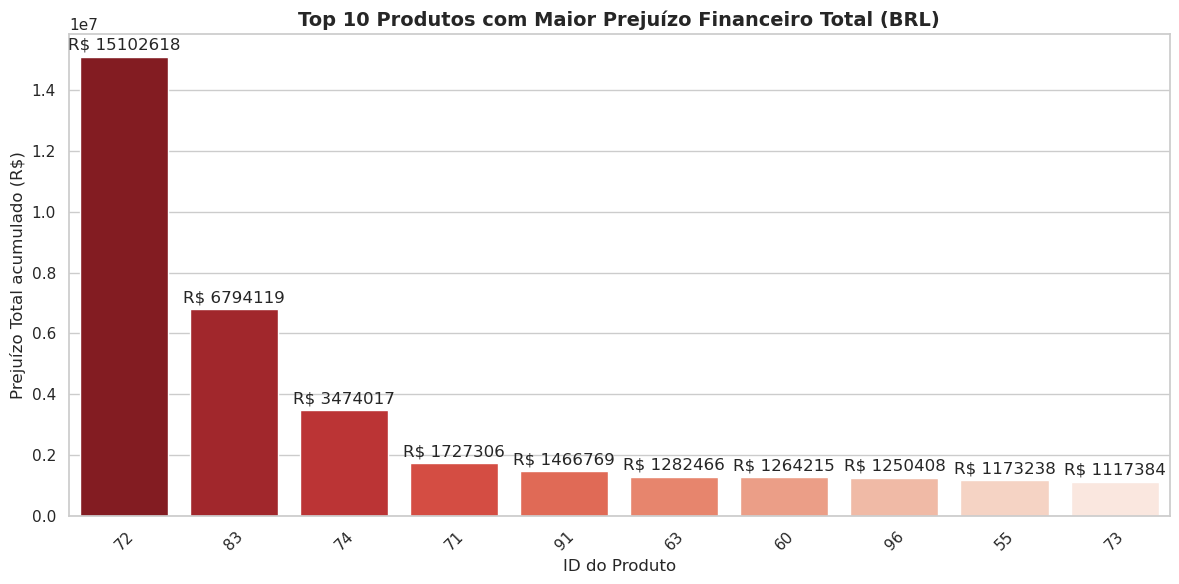

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados (pegando os 10 produtos com maior prejuízo total para o gráfico não ficar poluído)
df_plot = df_resultado_sql.head(10).copy()
df_plot['id_product'] = df_plot['id_product'].astype(str)  # Converter para string para o eixo X

# 2. Configurar o estilo do gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Criar o gráfico de barras para o Prejuízo Total
ax = sns.barplot(
    x='id_product', 
    y='prejuizo_total', 
    data=df_plot, 
    palette='Reds_r'
)

# 4. Adicionar títulos e rótulos
plt.title('Top 10 Produtos com Maior Prejuízo Financeiro Total (BRL)', fontsize=14, fontweight='bold')
plt.xlabel('ID do Produto', fontsize=12)
plt.ylabel('Prejuízo Total acumulado (R$)', fontsize=12)

# 5. Exibir os valores em cima das barras (opcional, para melhor leitura)
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.0f', padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### ***Importante***

Utilizei a data de 01 de Abril de 2016 até 31 de Dezembro de 2025, que são as datas mínimas e máximas de vendas.O prejuízo foi contabilizado como receita - custo, isso é: TotalVendidoEmReais - (precoUnitario * quantidadeComprada * taxa de cambio). Quanto as suposições: Como o catálogo de fornecedores possui preços que variam no tempo, assumi que o custo unitário válido para a transação é aquele com a start_date mais recente em relação à data da venda.Para vendas ocorridas em finais de semana ou feriados (onde não há cotação oficial), a lógica de cruzamento buscou a última cotação disponível imediatamente anterior.
Escopo Financeiro: Conforme solicitado, ignorei impostos e fretes, focando exclusivamente na margem bruta entre o custo de aquisição em dólar e o preço de venda final.